# Causal Inference

Correlation tells us two variables move together. **Causation** tells us that changing one variable *produces* a change in the other. Establishing causation from observational data is one of the hardest problems in statistics.

The **fundamental problem of causal inference:** we can never observe both the treated and untreated outcome for the same unit at the same time. We can only observe one *potential outcome*.

## Confounding Variables

A **confounder** is a variable that causally affects both the treatment and the outcome, creating a spurious correlation.

Classic example: ice cream sales and drowning deaths are positively correlated — but the confounder is *summer/heat* (causes both). Ice cream doesn't cause drowning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)
n = 200

# Confounding example: education -> income, age -> both education AND income
age       = rng.integers(22, 65, size=n).astype(float)
education = 10 + 0.15 * age + rng.normal(0, 2, size=n)   # older -> more education (time)
income    = 20 + 1.5  * age + 2.5 * education + rng.normal(0, 10, size=n)  # age & edu -> income

# Naive correlation (ignores age confounder)
r_naive, p_naive = stats.pearsonr(education, income)

# Partial correlation: correlation between education and income CONTROLLING for age
# Residualise both on age
_, _, r_edu_age, _, _ = stats.linregress(age, education)
edu_resid = education - (np.polyval(np.polyfit(age, education, 1), age))
inc_resid = income    - (np.polyval(np.polyfit(age, income,    1), age))
r_partial, p_partial = stats.pearsonr(edu_resid, inc_resid)

print('Confounding Example: Age confounds Education-Income relationship')
print(f'  Naive (unadjusted) r(education, income)    : {r_naive:+.4f}, p={p_naive:.4f}')
print(f'  Partial (age-adjusted) r(education|age, income|age): {r_partial:+.4f}, p={p_partial:.4f}')
print()
print('Controlling for age reduces the correlation — age was inflating it.')


Confounding Example: Age confounds Education-Income relationship
  Naive (unadjusted) r(education, income)    : +0.7333, p=0.0000
  Partial (age-adjusted) r(education|age, income|age): +0.4427, p=0.0000

Controlling for age reduces the correlation — age was inflating it.


## Simpson's Paradox

A trend that appears in separate groups **reverses or disappears** when the groups are combined. This is caused by an imbalanced confounding variable.

In [2]:
# Simpson's Paradox: treatment appears harmful overall but beneficial in each subgroup
# Classic setup: treatment uptake differs between mild and severe cases

# Severe cases (most are treated; all have low recovery)
n_severe = 700
severe = pd.DataFrame({
    'group'    : ['Severe']*n_severe,
    'treated'  : [1]*500 + [0]*200,
    'recovered': [1]*200 + [0]*300 + [1]*30 + [0]*170
})

# Mild cases (most are NOT treated; all have high recovery)
n_mild = 300
mild = pd.DataFrame({
    'group'    : ['Mild']*n_mild,
    'treated'  : [1]*100 + [0]*200,
    'recovered': [1]*90 + [0]*10 + [1]*160 + [0]*40
})

df = pd.concat([severe, mild], ignore_index=True)

print('Recovery rates by treatment:')
print()

# Within each group, treatment is beneficial
for group_name, group_df in df.groupby('group'):
    r_treated   = group_df[group_df.treated==1]['recovered'].mean()
    r_untreated = group_df[group_df.treated==0]['recovered'].mean()
    print(f'{group_name} cases:')
    print(f'  Treated   recovery rate: {r_treated:.0%}')
    print(f'  Untreated recovery rate: {r_untreated:.0%}')
    print(f'  Treatment benefit: {r_treated-r_untreated:+.0%}')
    print()

# Aggregated (confounded)
overall_treated   = df[df.treated==1]['recovered'].mean()
overall_untreated = df[df.treated==0]['recovered'].mean()
print('AGGREGATED (confounded by severity):')
print(f'  Treated   recovery rate: {overall_treated:.0%}')
print(f'  Untreated recovery rate: {overall_untreated:.0%}')
print(f'  Apparent treatment effect: {overall_treated-overall_untreated:+.0%}  <-- MISLEADING!')
print()
print('Treatment looks harmful in aggregate because it was disproportionately')
print('given to severe cases who have low baseline recovery regardless.')


Recovery rates by treatment:

Mild cases:
  Treated   recovery rate: 90%
  Untreated recovery rate: 80%
  Treatment benefit: +10%

Severe cases:
  Treated   recovery rate: 40%
  Untreated recovery rate: 15%
  Treatment benefit: +25%

AGGREGATED (confounded by severity):
  Treated   recovery rate: 48%
  Untreated recovery rate: 48%
  Apparent treatment effect: +1%  <-- MISLEADING!

Treatment looks harmful in aggregate because it was disproportionately
given to severe cases who have low baseline recovery regardless.


## Difference-in-Differences (DiD)

DiD estimates a causal effect from observational data by comparing the **change** in outcome for a treated group vs a control group across two time periods. It controls for time-invariant confounders.

$$\text{DiD estimate} = (\bar{Y}_{\text{treated, post}} - \bar{Y}_{\text{treated, pre}}) - (\bar{Y}_{\text{control, post}} - \bar{Y}_{\text{control, pre}})$$

**Key assumption (parallel trends):** absent the treatment, both groups would have had the same time trend.

Difference-in-Differences
  Control  pre/post means : 50.5 → 54.8  (change=+4.3)
  Treated  pre/post means : 47.6 → 67.5  (change=+19.9)
  DiD estimate            : 19.9 - 4.3 = 15.7
  True treatment effect   : 15



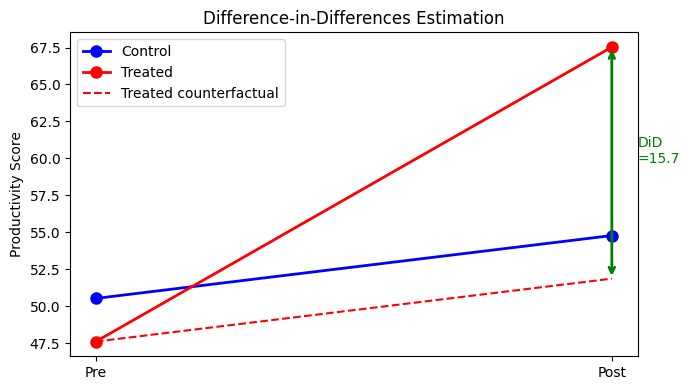

In [3]:
# DiD Example: Effect of a training programme on employee productivity
rng = np.random.default_rng(seed=42)
n_each = 60

# True treatment effect = +15 productivity points
true_effect = 15

# Control group: productivity improves slightly over time (trend = +5)
ctrl_pre  = rng.normal(50, 8, n_each)
ctrl_post = ctrl_pre + 5 + rng.normal(0, 4, n_each)

# Treated group: same trend + treatment effect
trt_pre   = rng.normal(48, 8, n_each)   # slightly different baseline
trt_post  = trt_pre + 5 + true_effect + rng.normal(0, 4, n_each)

# DiD estimate
delta_control = ctrl_post.mean() - ctrl_pre.mean()
delta_treated = trt_post.mean()  - trt_pre.mean()
did_estimate  = delta_treated - delta_control

print('Difference-in-Differences')
print(f'  Control  pre/post means : {ctrl_pre.mean():.1f} → {ctrl_post.mean():.1f}  (change={delta_control:+.1f})')
print(f'  Treated  pre/post means : {trt_pre.mean():.1f} → {trt_post.mean():.1f}  (change={delta_treated:+.1f})')
print(f'  DiD estimate            : {delta_treated:.1f} - {delta_control:.1f} = {did_estimate:.1f}')
print(f'  True treatment effect   : {true_effect}')
print()

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
periods = [0, 1]
ax.plot(periods, [ctrl_pre.mean(), ctrl_post.mean()], 'b-o', lw=2, ms=8, label='Control')
ax.plot(periods, [trt_pre.mean(),  trt_post.mean()],  'r-o', lw=2, ms=8, label='Treated')
# Counterfactual trend for treated (parallel to control)
counterfactual_post = trt_pre.mean() + delta_control
ax.plot(periods, [trt_pre.mean(), counterfactual_post], 'r--', lw=1.5, label='Treated counterfactual')
ax.annotate('', xy=(1, trt_post.mean()), xytext=(1, counterfactual_post),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(1.05, (trt_post.mean()+counterfactual_post)/2,
        f'DiD\n={did_estimate:.1f}', color='green', fontsize=10)
ax.set_xticks([0,1])
ax.set_xticklabels(['Pre', 'Post'])
ax.set_ylabel('Productivity Score')
ax.set_title('Difference-in-Differences Estimation')
ax.legend()
plt.tight_layout()
plt.show()


## The Gold Standard: Randomised Controlled Trials (RCTs)

Random assignment of treatment **breaks the link** between any confounders and the treatment, making treated and control groups comparable in expectation on all variables — both observed and unobserved.

When RCTs are impossible (ethical, practical, historical data), we use:
- **Instrumental Variables (IV)** — a variable that affects treatment but not outcome directly
- **Regression Discontinuity (RD)** — exploit sharp cutoffs in treatment assignment
- **Difference-in-Differences** — exploit pre/post variation with a control group
- **Matching / Propensity Score Matching** — match treated and control units on observed covariates

---
## ML/AI Connection

- **Counterfactual ML:** uplift modelling and causal forests estimate the individual treatment effect (ITE) — how much would *this specific user's* outcome change if treated?
- **Debiasing training data:** spurious correlations in training data (selection bias, confounders) cause ML models to learn the wrong features — causal reasoning identifies which associations are spurious.
- **Offline policy evaluation:** reinforcement learning from logged data faces the same confounding problem as observational studies — importance sampling corrects for this.
- **DoWhy / CausalML** are Python libraries implementing causal inference methods (IV, RD, DiD, propensity score matching) for ML practitioners.
